In [ ]:
import pandas as pd
import numpy as np
import spacy
import re
import os
from math import ceil

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "lemmatizer"])

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df1= pd.read_excel('relations_cancer.xlsx')

In [ ]:
df2= pd.read_excel('relations_diabetes.xlsx')

In [ ]:
df3= pd.read_excel('relations_heart.xlsx')

In [ ]:
df4= pd.read_excel('relations_lung.xlsx')

In [ ]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)


In [ ]:
df.to_excel("customdataset.xlsx", index=False)
from google.colab import files

files.download("customdataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.columns

Index(['PMID', 'authors', 'affiliation', 'country', 'journal', 'year', 'title',
       'abstract', 'filtered_abstract', 'sentence', 'tokens', 'tags',
       'disease', 'factor', 'relation', 'environmental_factors'],
      dtype='object')

In [ ]:
df['relation'].value_counts()

,count
relation,
positive,31395
unknown,6662
negative,30


In [ ]:
df = df[df['relation'] == 'positive'].reset_index(drop=True)
print(df.head())


       PMID                                            authors  \
0  41130130  Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...   
1  41187632  Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...   
2  40756629  Wong-Siegel Jeannette R; Glatz Andrew C; Zampi...   
3  41224127  Salmon Charlotte; Some André; Jacquemin Bénédi...   
4  41260324  Ghanem Laura; Moubarak Antonia; Kotaich Jana; ...   

                                         affiliation         country  \
0  Department of Geosciences, Georgia State Unive...             Usa   
1  Technological Institute of Ornamental Rocks an...           Spain   
2  New York-Presbyterian Morgan Stanley Children'...             NaN   
3  Université Paris Cité and Université Sorbonne ...          France   
4  Faculty of Medical Sciences, Lebanese Universi...  United Kingdom   

                                             journal  year  \
0             Journal of environmental radioactivity  2026   
1             Journal of environmental radioac

In [ ]:
df.columns

Index(['PMID', 'authors', 'affiliation', 'country', 'journal', 'year', 'title',
       'abstract', 'filtered_abstract', 'sentence', 'tokens', 'tags',
       'diseases', 'environmental_factors', 'relation'],
      dtype='object')

# **understudied factors**

*   Step 1: Split comma-separated values in each cell
*   step 2: Strip whitespace and convert to lowercase
*   step 3: Explode lists into one-disease-per-row( Each disease gets its own row, factors remain the same)
*   Step 4: Explode lists into one-factor-per-row ( Now each row is one disease–one factor (Cartesian product within original row)
*   Step 5: Count frequency of disease–factor pairs
*   Step 6: Identify understudied pairs (frequency = 1)









In [ ]:

# df["diseases"] = df["diseases"].str.split(",")
# df["environmental_factors"] = df["environmental_factors"].str.split(",")

df["diseases"] = df["diseases"].astype(str).str.split(",")
df["environmental_factors"] = df["environmental_factors"].astype(str).str.split(",")



In [ ]:
df["diseases"] = df["diseases"].apply(lambda x: [d.strip().lower() for d in x])
df["environmental_factors"] = df["environmental_factors"].apply(lambda x: [f.strip().lower() for f in x])

In [ ]:
df = df.explode("diseases")
df

,PMID,authors,affiliation,country,journal,year,title,abstract,filtered_abstract,sentence,tokens,tags,diseases,environmental_factors,relation
0,41130130,Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...,"Department of Geosciences, Georgia State Unive...",Usa,Journal of environmental radioactivity,2026,Participatory science to action: Radon literac...,Low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,"['low', 'radon', 'testing', 'rates', 'in', 'co...","['O', 'B-radiation_exposures', 'I-radiation_ex...",cancer,[radon testing],positive
0,41130130,Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...,"Department of Geosciences, Georgia State Unive...",Usa,Journal of environmental radioactivity,2026,Participatory science to action: Radon literac...,Low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,"['low', 'radon', 'testing', 'rates', 'in', 'co...","['O', 'B-radiation_exposures', 'I-radiation_ex...",lung,[radon testing],positive
1,41187632,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,"['radon', 'is', 'recognised', 'as', 'the', 'se...","['B-hazardous_substances', 'O', 'O', 'O', 'O',...",cancer,"[radon, radon concentrations]",positive
1,41187632,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,"['radon', 'is', 'recognised', 'as', 'the', 'se...","['B-hazardous_substances', 'O', 'O', 'O', 'O',...",lung,"[radon, radon concentrations]",positive
2,40756629,Wong-Siegel Jeannette R; Glatz Andrew C; Zampi...,New York-Presbyterian Morgan Stanley Children'...,NaN,"Radiation physics and chemistry (Oxford, Engla...",2026,Organ-level radiation dose estimations from ca...,Children with congenital heart disease (CHD) u...,children with congenital heart disease chd und...,children with congenital heart disease chd und...,"['children', 'with', 'congenital', 'heart', 'd...","['O', 'O', 'O', 'B-heart_disease', 'I-heart_di...",heart disease,"[ionizing radiation, fluoroscopy]",positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of medicine,1975,A clinical and lung function study of chronic ...,A prevalence survey on the island of Karkar ha...,a prevalence survey on the island of karkar ha...,a prevalence survey on the island of karkar ha...,"['a', 'prevalence', 'survey', 'on', 'the', 'is...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",chronic bronchitis,[tobacco],positive
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of medicine,1975,A clinical and lung function study of chronic ...,A prevalence survey on the island of Karkar ha...,a prevalence survey on the island of karkar ha...,a prevalence survey on the island of karkar ha...,"['a', 'prevalence', 'survey', 'on', 'the', 'is...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",chronic,[tobacco],positive
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of medicine,1975,A clinical and lung function study of chronic ...,A prevalence survey on the island of Karkar ha...,a prevalence survey on the island of karkar ha...,a prevalence survey on the island of karkar ha...,"['a', 'prevalence', 'survey', 'on', 'the', 'is...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",emphys

In [ ]:
df = df.explode("environmental_factors")
df

,PMID,authors,affiliation,country,journal,year,title,abstract,filtered_abstract,sentence,tokens,tags,diseases,environmental_factors,relation
0,41130130,Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...,"Department of Geosciences, Georgia State Unive...",Usa,Journal of environmental radioactivity,2026,Participatory science to action: Radon literac...,Low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,"['low', 'radon', 'testing', 'rates', 'in', 'co...","['O', 'B-radiation_exposures', 'I-radiation_ex...",cancer,radon testing,positive
0,41130130,Dai Dajun; Jelks Na'Taki Osborne; Smith Gwendy...,"Department of Geosciences, Georgia State Unive...",Usa,Journal of environmental radioactivity,2026,Participatory science to action: Radon literac...,Low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,low radon testing rates in communities of colo...,"['low', 'radon', 'testing', 'rates', 'in', 'co...","['O', 'B-radiation_exposures', 'I-radiation_ex...",lung,radon testing,positive
1,41187632,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,"['radon', 'is', 'recognised', 'as', 'the', 'se...","['B-hazardous_substances', 'O', 'O', 'O', 'O',...",cancer,radon,positive
1,41187632,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,"['radon', 'is', 'recognised', 'as', 'the', 'se...","['B-hazardous_substances', 'O', 'O', 'O', 'O',...",cancer,radon concentrations,positive
1,41187632,Tejado-Ramos Juan-José; Alvarez-Toral Aitor; G...,Technological Institute of Ornamental Rocks an...,Spain,Journal of environmental radioactivity,2026,Evaluating overestimated radon risk in predict...,Radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,radon is recognised as the second most signifi...,"['radon', 'is', 'recognised', 'as', 'the', 'se...","['B-hazardous_substances', 'O', 'O', 'O', 'O',...",lung,radon,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of medicine,1975,A clinical and lung function study of chronic ...,A prevalence survey on the island of Karkar ha...,a prevalence survey on the island of karkar ha...,a prevalence survey on the island of karkar ha...,"['a', 'prevalence', 'survey', 'on', 'the', 'is...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",chronic bronchitis,tobacco,positive
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of medicine,1975,A clinical and lung function study of chronic ...,A prevalence survey on the island of Karkar ha...,a prevalence survey on the island of karkar ha...,a prevalence survey on the island of karkar ha...,"['a', 'prevalence', 'survey', 'on', 'the', 'is...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",chronic,tobacco,positive
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of medicine,1975,A clinical and lung function study of chronic ...,A prevalence survey on the island of Karkar ha...,a prevalence survey on the island of karkar ha...,a prevalence survey on the island of karkar ha...,"['a', 'prevalence', 'survey', 'on', 'the', 'is...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",emphysema,tobacco,positive
31394,1058671,Anderson H R,NaN,NaN,Australian and New Zealand journal of

In [ ]:

df = df.rename(columns={
    "diseases": "disease",
    "environmental_factors": "factor"
}).reset_index(drop=True)


pair_counts = (
    df.groupby(["disease", "factor"])
      .size()
      .reset_index(name="frequency")
)


In [ ]:

understudied_pairs = pair_counts[pair_counts["frequency"] == 1]

print("\nUnderstudied disease–factor pairs (frequency = 1):\n")
print(understudied_pairs)



Understudied disease–factor pairs (frequency = 1):

                      disease                            factor  frequency
1     acute coronary syndrome                      black carbon          1
2     acute coronary syndrome                           cadmium          1
3     acute coronary syndrome                   carbon monoxide          1
4     acute coronary syndrome                                co          1
7     acute coronary syndrome                              dust          1
...                       ...                               ...        ...
9050                    wilms                          ionizing          1
9051                    wilms                ionizing radiation          1
9053                    wilms                 perchloroethylene          1
9055                    wilms  polycyclic aromatic hydrocarbons          1
9057                    wilms                 radiation therapy          1

[3457 rows x 3 columns]


In [ ]:
understudied_pairs

,disease,factor,frequency
1,acute coronary syndrome,black carbon,1
2,acute coronary syndrome,cadmium,1
3,acute coronary syndrome,carbon monoxide,1
4,acute coronary syndrome,co,1
7,acute coronary syndrome,dust,1
...,...,...,...
9050,wilms,ionizing,1
9051,wilms,ionizing radiation,1
9053,wilms,perchloroethylene,1
9055,wilms,polycyclic aromatic hydrocarbons,1


# Group by factor and count unique diseases


In [ ]:
disease_diversity = (
    df.groupby("factor")["disease"]
      .nunique()
      .reset_index()
      .rename(columns={"disease": "unique_disease_count"})
      .sort_values(by="unique_disease_count", ascending=False)
)

print(disease_diversity)


                     factor  unique_disease_count
178                    lead                   131
217   occupational exposure                   113
321                 tobacco                   112
273            radiotherapy                   102
9             air pollution                   101
..                      ...                   ...
90      cockroach allergens                     1
308                sulfites                     1
79         chlorine dioxide                     1
61   butyl benzyl phthalate                     1
41                biosolids                     1

[354 rows x 2 columns]


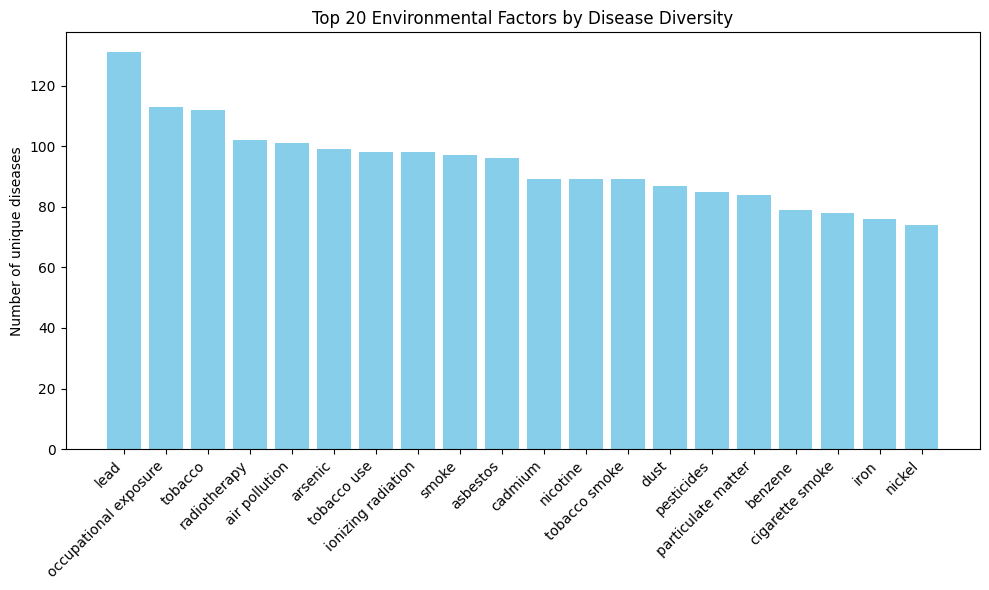

In [ ]:
import matplotlib.pyplot as plt

top20 = disease_diversity.sort_values(by="unique_disease_count", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.bar(top20["factor"], top20["unique_disease_count"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of unique diseases")
plt.tight_layout()
plt.savefig("high_res_plot.png", dpi=600)
plt.show()



Frequency of each factor across all pairs
Disease diversity per factor
Combine into a single DataFrame
Optional: Sort by frequency and diversity for insight


In [ ]:

factor_frequency = df.groupby("factor").size().reset_index(name="pair_count")

disease_diversity = df.groupby("factor")["disease"].nunique().reset_index(name="unique_disease_count")

factor_summary = pd.merge(factor_frequency, disease_diversity, on="factor")

factor_summary = factor_summary.sort_values(by=["pair_count", "unique_disease_count"], ascending=False)

print(factor_summary)


                    factor  pair_count  unique_disease_count
178                   lead       17341                   131
321                tobacco        8022                   112
9            air pollution        6393                   101
28                asbestos        5228                    96
217  occupational exposure        4142                   113
..                     ...         ...                   ...
126               ergotism           1                     1
142                  gamma           1                     1
194            mold spores           1                     1
279         radon in water           1                     1
308               sulfites           1                     1

[354 rows x 3 columns]


# calculated impact score: impact_score = pair_count * unique_disease_count


In [ ]:
factor_summary["impact_score"] = factor_summary["pair_count"] * factor_summary["unique_disease_count"]

factor_summary = factor_summary.sort_values(by="impact_score", ascending=False)

print(factor_summary)


                     factor  pair_count  unique_disease_count  impact_score
178                    lead       17341                   131       2271671
321                 tobacco        8022                   112        898464
9             air pollution        6393                   101        645693
28                 asbestos        5228                    96        501888
217   occupational exposure        4142                   113        468046
..                      ...         ...                   ...           ...
41                biosolids           1                     1             1
61   butyl benzyl phthalate           1                     1             1
142                   gamma           1                     1             1
279          radon in water           1                     1             1
308                sulfites           1                     1             1

[354 rows x 4 columns]


In [ ]:

understudied_factors = factor_summary[factor_summary["impact_score"] == 1]["factor"].tolist()

print("Factors with impact factor = 1 (very understudied):")
print(understudied_factors)
print(len(understudied_factors))


Factors with impact factor = 1 (very understudied):
['ergotism', 'mold spores', 'chlorine dioxide', 'alkylphenols', 'biosolids', 'butyl benzyl phthalate', 'gamma', 'radon in water', 'sulfites']
9


In [ ]:

impact_one_factors = factor_summary[factor_summary["impact_score"] == 1]["factor"].tolist()

factors_with_disease = df[df["factor"].isin(impact_one_factors)]

print("\nFactors with impact score = 1 and their diseases:\n")
print(factors_with_disease[['disease','factor','relation']])



Factors with impact score = 1 and their diseases:

       disease                  factor  relation
908     cancer               biosolids  positive
7102    cancer          radon in water  positive
11201   cancer                   gamma  positive
39428   cancer            alkylphenols  positive
49008   cancer                ergotism  positive
58677   cancer        chlorine dioxide  positive
120808  asthma  butyl benzyl phthalate  positive
122391  asthma             mold spores  positive
128136  asthma                sulfites  positive


In [ ]:
import pandas as pd
from scipy.stats import linregress

df = df[df["relation"] == "positive"].copy()

df["environmental_factors"] = (
    df["factor"]
    .str.lower()
    .str.split(",")
)

df = df.explode("environmental_factors")
df["environmental_factors"] = df["environmental_factors"].str.strip()

factor_year_counts = (
    df.groupby(["environmental_factors", "year"])
      .size()
      .reset_index(name="count")
)


first_year = (
    factor_year_counts
    .groupby("environmental_factors")["year"]
    .min()
    .reset_index(name="first_year")
)


growth_records = []

for factor, group in factor_year_counts.groupby("environmental_factors"):
    if len(group) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        group["year"], group["count"]
    )

    growth_records.append({
        "environmental_factors": factor,
        "growth_rate": slope,
        "trend_strength": r_value ** 2
    })

growth_df = pd.DataFrame(growth_records)


factor_time_summary = first_year.merge(
    growth_df,
    on="environmental_factors",
    how="left"
)


def growth_label(slope):
    if pd.isna(slope):
        return "Insufficient data"
    elif slope > 1.0:
        return "Very High"
    elif slope > 0.3:
        return "High"
    elif slope > 0.05:
        return "Moderate"
    else:
        return "Low"

factor_time_summary["growth_level"] = (
    factor_time_summary["growth_rate"].apply(growth_label)
)


factor_time_summary = factor_time_summary.sort_values(
    by=["first_year", "growth_rate"],
    ascending=[False, False]
)

print("\n📈 Emerging Environmental Risk Factors (Time-Aware)\n")
print(factor_time_summary)



📈 Emerging Environmental Risk Factors (Time-Aware)

     environmental_factors  first_year  growth_rate  trend_strength  \
11         airborne toxins        2025          NaN             NaN   
41               biosolids        2025          NaN             NaN   
86                citrates        2025          NaN             NaN   
190          microplastics        2025          NaN             NaN   
244          pfoa exposure        2025          NaN             NaN   
..                     ...         ...          ...             ...   
28                asbestos        1973     4.028786        0.844839   
119                   dust        1973     1.319015        0.725781   
174                   iron        1970     0.640580        0.468347   
203                 nickel        1970     0.514019        0.474549   
217  occupational exposure        1969     3.396216        0.834696   

          growth_level  
11   Insufficient data  
41   Insufficient data  
86   Insufficient d

In [ ]:
import pandas as pd


df_pos = df[df["relation"] == "positive"].copy()

df_pos["disease"] = df_pos["disease"].str.lower().str.split(",")
df_pos = df_pos.explode("disease")
df_pos["disease"] = df_pos["disease"].str.strip()

df_pos["factor"] = df_pos["factor"].str.lower().str.split(",")
df_pos = df_pos.explode("factor")
df_pos["factor"] = df_pos["factor"].str.strip()

factor_degree = (
    df_pos.groupby("factor")["disease"]
    .nunique()
    .reset_index(name="disease_count")
)

disease_degree = (
    df_pos.groupby("disease")["factor"]
    .nunique()
    .reset_index(name="factor_count")
)

sparse_factors = factor_degree[factor_degree["disease_count"] == 1]

sparse_diseases = disease_degree[disease_degree["factor_count"] == 1]

print("\nSparse Factors (1 disease only):")
print(sparse_factors.sort_values("disease_count"))

print("\nSparse Diseases (1 factor only):")
print(sparse_diseases.sort_values("factor_count"))


Sparse Factors (1 disease only):
                     factor  disease_count
8      agricultural burning              1
10       airborne chemicals              1
13             alkylphenols              1
16         anesthetic gases              1
41                biosolids              1
61   butyl benzyl phthalate              1
79         chlorine dioxide              1
90      cockroach allergens              1
126                ergotism              1
142                   gamma              1
177           latex allergy              1
194             mold spores              1
241              pet dander              1
279          radon in water              1
308                sulfites              1

Sparse Diseases (1 factor only):
                            disease  factor_count
30                   chondrosarcoma             1
44                craniopharyngioma             1
45                        cutaneous             1
63                       hairy cell         

In [ ]:

if "factor_time_summary" in globals():

    factor_time_summary = factor_time_summary.rename(
        columns={"environmental_factors": "factor"}
    )

    elite_factors = factor_time_summary.merge(
        factor_degree,
        on="factor",
        how="left"
    )
    elite_factors = elite_factors[
        (elite_factors["disease_count"] == 1) &
        (elite_factors["first_year"] >= 2020)
    ]

    print("\nEmerging Sparse Factors (1 disease, post-2020):")
    print(elite_factors.sort_values("first_year", ascending=False))




Emerging Sparse Factors (1 disease, post-2020):
                  factor  first_year  growth_rate  trend_strength  \
1              biosolids        2025          NaN             NaN   
11        radon in water        2023          NaN             NaN   
15  agricultural burning        2022          0.0             NaN   
19                 gamma        2022          NaN             NaN   

         growth_level  disease_count  
1   Insufficient data              1  
11  Insufficient data              1  
15                Low              1  
19  Insufficient data              1  


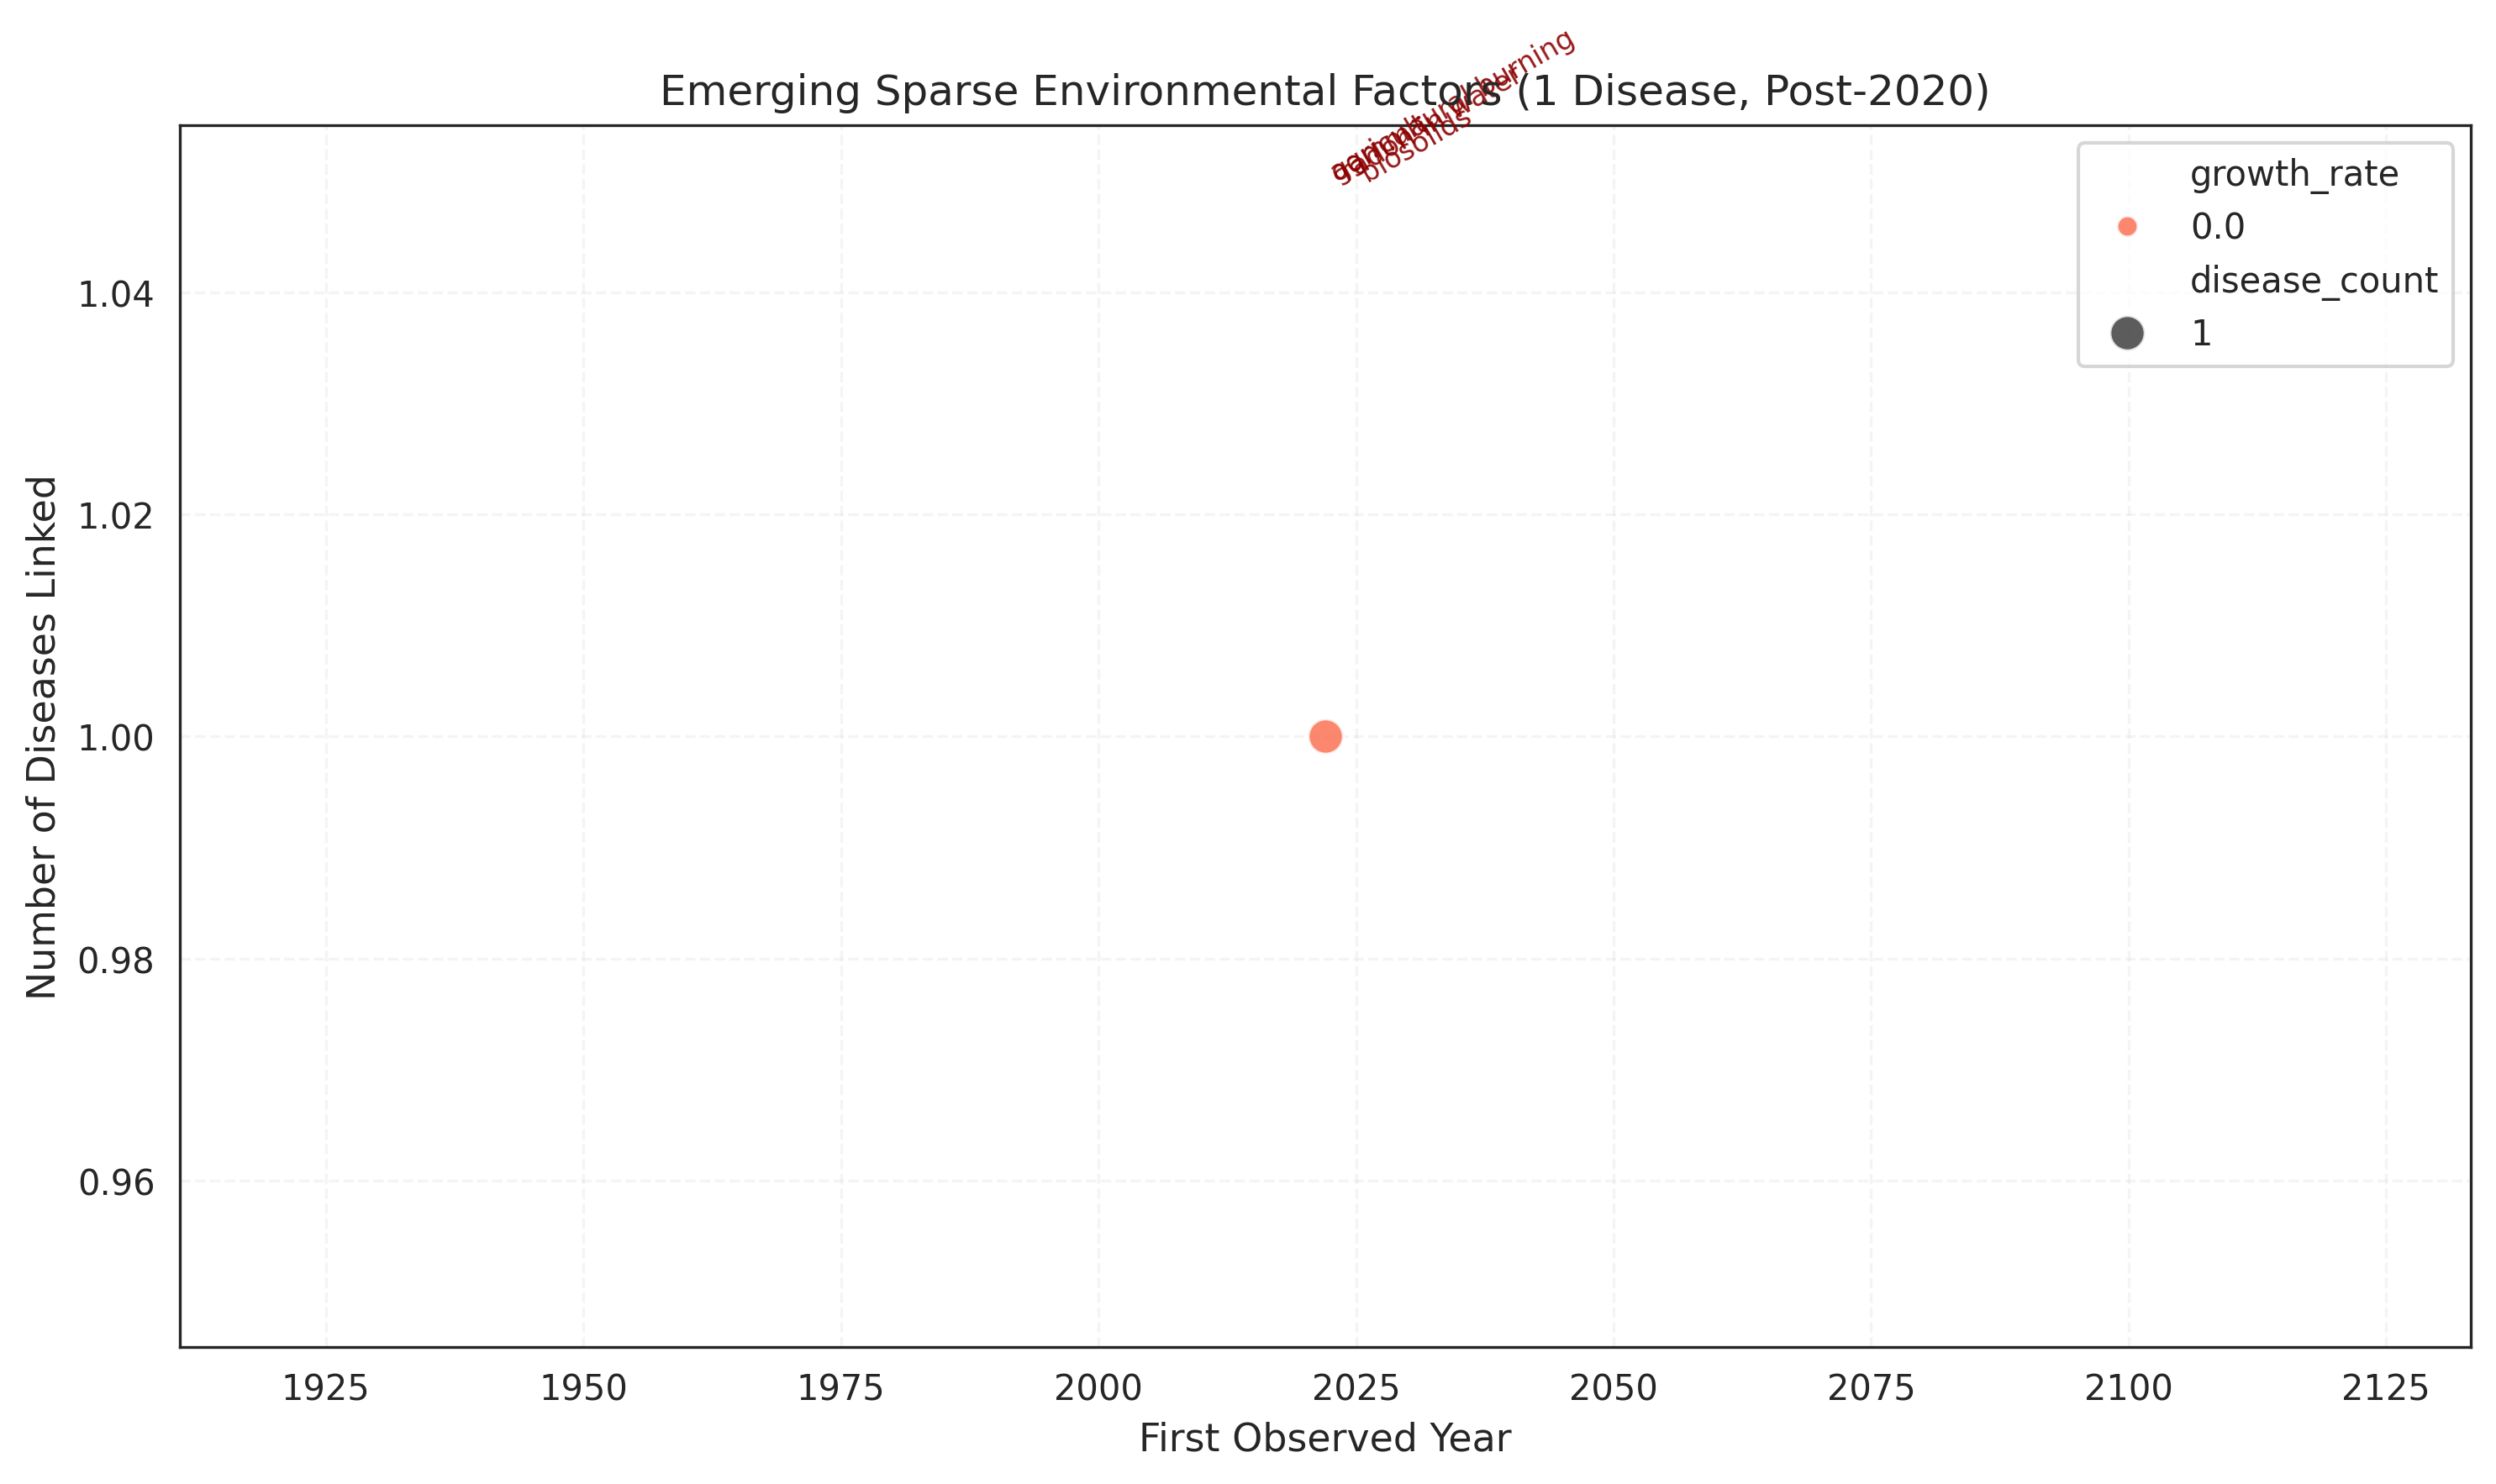

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


if "elite_factors" in globals() and not elite_factors.empty:

    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "figure.dpi": 300
    })

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=elite_factors,
        x="first_year",
        y="disease_count",
        size="disease_count",
        hue="growth_rate" if "growth_rate" in elite_factors.columns else "disease_count",
        palette="Reds",
        sizes=(100, 400),
        alpha=0.8,
        legend=True
    )

    for _, row in elite_factors.iterrows():
        plt.text(
            row["first_year"] + 0.05,
            row["disease_count"] + 0.05,
            row["factor"],
            fontsize=8,
            color='darkred',
            rotation=30,
            alpha=0.9
        )

    plt.xlabel("First Observed Year")
    plt.ylabel("Number of Diseases Linked")
    plt.title("Emerging Sparse Environmental Factors (1 Disease, Post-2020)")
    plt.grid(alpha=0.2, linestyle="--")
    plt.tight_layout()
    plt.show()

else:
    print("No elite factors to plot (check your filtering criteria).")


In [ ]:
FINAL_DISEASE_NAMES = {
    "heart_disease": [
        "heart","heart disease","cardiovascular disease","cardiovascular diseases","cvd","coronary heart disease","coronary artery disease","ischemic heart disease", "atherosclerotic cardiovascular disease","ascvd","myocardial infarction","heart attack","acute coronary syndrome","angina pectoris","heart failure","congestive heart failure","hypertensive heart disease","peripheral artery disease","peripheral vascular disease","stroke","cerebrovascular disease","cardiac disease","vascular disease"
    ],

    "diabetes": [
        "diabetes", "diabetes mellitus", "type 1 diabetes","type i diabetes","t1d","type 2 diabetes","type ii diabetes","t2d","gestational diabetes","adult-onset diabetes", "juvenile diabetes","hyperglycemia", "chronic hyperglycemia","insulin resistance","impaired glucose tolerance","impaired fasting glucose","prediabetes","metabolic disease","metabolic disorder","glucose metabolism disorder", "diabetic disease"
    ],

    "lung_disease": [
        "lung disease",
        "chronic lung disease",
        "respiratory disease",
        "respiratory diseases",
        "chronic respiratory disease",
        "pulmonary disease",
        "pulmonary disorders",
        "chronic obstructive pulmonary disease",
        "copd",
        "asthma",
        "chronic bronchitis",
        "emphysema",
        "interstitial lung disease",
        "ild",
        "pulmonary fibrosis",
        "restrictive lung disease",
        "obstructive lung disease",
        "airway disease",
        "lower respiratory disease",
        "respiratory illness"
    ],

    "cancer": [
        "cancer",
        "cancers",
        "malignancy",
        "malignancies",
        "malignant neoplasm",
        "neoplasm",
        "neoplasms",
        "tumor",
        "tumors",
        "carcinoma",
        "adenocarcinoma",
        "squamous cell carcinoma",
        "sarcoma",
        "lymphoma",
        "leukemia",
        "solid tumor",
        "metastatic cancer",
        "advanced cancer",
        "oncologic disease",
        "oncological disease",
    "Adenocarcinoma", "Basal Cell Carcinoma", "Squamous Cell Carcinoma",
    "Renal Cell Carcinoma", "Transitional Cell Carcinoma", "Ductal Carcinoma In Situ",
    "Invasive Ductal Carcinoma", "Invasive Lobular Carcinoma", "Hepatocellular Carcinoma",
    "Adrenocortical Carcinoma", "Bronchioloalveolar Carcinoma", "Merkel Cell Carcinoma",
    "Sebaceous Carcinoma", "Acinar Cell Carcinoma", "Papillary Carcinoma",
    "Follicular Carcinoma", "Medullary Carcinoma", "Mucoepidermoid Carcinoma",
    "Osteosarcoma", "Chondrosarcoma", "Ewing Sarcoma", "Liposarcoma",
    "Rhabdomyosarcoma", "Leiomyosarcoma", "Angiosarcoma", "Kaposi Sarcoma",
    "Synovial Sarcoma", "Fibrosarcoma", "Malignant Fibrous Histiocytoma",
    "Alveolar Soft Part Sarcoma", "Clear Cell Sarcoma", "Desmoplastic Small Round Cell Tumor",
    "Epithelioid Sarcoma", "Gastrointestinal Stromal Tumor",
    "Acute Lymphoblastic Leukemia", "Acute Myeloid Leukemia",
    "Chronic Lymphocytic Leukemia", "Chronic Myeloid Leukemia",
    "Hairy Cell Leukemia", "Acute Promyelocytic Leukemia",
    "Chronic Myelomonocytic Leukemia", "Juvenile Myelomonocytic Leukemia",
    "Large Granular Lymphocytic Leukemia", "Blastic Plasmacytoid Dendritic Cell Neoplasm",
    "Hodgkin Lymphoma", "Non-Hodgkin Lymphoma", "Diffuse Large B-Cell Lymphoma",
    "Follicular Lymphoma", "Mantle Cell Lymphoma", "Burkitt Lymphoma",
    "Marginal Zone Lymphoma", "Primary Central Nervous System Lymphoma",
    "Primary Mediastinal B-Cell Lymphoma", "Anaplastic Large Cell Lymphoma",
    "Peripheral T-Cell Lymphoma", "Cutaneous T-Cell Lymphoma",
    "Mycosis Fungoides", "Sézary Syndrome", "Lymphoplasmacytic Lymphoma",
    "Primary Effusion Lymphoma", "Post-Transplant Lymphoproliferative Disorder",
    "Glioblastoma", "Astrocytoma", "Oligodendroglioma", "Ependymoma",
    "Medulloblastoma", "Meningioma", "Pituitary Adenoma", "Craniopharyngioma",
    "Schwannoma", "Pineoblastoma", "Pineocytoma", "Chordoma",
    "Central Neurocytoma", "Dysembryoplastic Neuroepithelial Tumor",
    "Neuroblastoma", "Retinoblastoma", "Wilms Tumor", "Rhabdoid Tumor",
    "Hepatoblastoma", "Germ Cell Tumor", "Osteosarcoma (Pediatric)",
    "Ewing Sarcoma (Pediatric)", "Rhabdomyosarcoma (Pediatric)",
    "Ovarian Cancer", "Cervical Cancer", "Endometrial Cancer",
    "Uterine Cancer", "Vulvar Cancer", "Vaginal Cancer",
    "Gestational Trophoblastic Disease", "Choriocarcinoma",
    "Ovarian Germ Cell Tumor", "Fallopian Tube Cancer",
    "Prostate Cancer", "Testicular Cancer", "Bladder Cancer",
    "Kidney Cancer", "Penile Cancer", "Urethral Cancer",
    "Renal Pelvis Cancer", "Ureter Cancer",
    "Colorectal Cancer", "Colon Cancer", "Rectal Cancer",
    "Stomach Cancer", "Esophageal Cancer", "Pancreatic Cancer",
    "Liver Cancer", "Gallbladder Cancer", "Bile Duct Cancer",
    "Anal Cancer", "Small Intestine Cancer", "Appendiceal Cancer",
    "Peritoneal Cancer", "Gastroesophageal Junction Cancer",
    "Oral Cancer", "Tongue Cancer", "Throat Cancer",
    "Laryngeal Cancer", "Nasopharyngeal Cancer",
    "Oropharyngeal Cancer", "Hypopharyngeal Cancer",
    "Salivary Gland Cancer", "Paranasal Sinus Cancer",
    "Nasal Cavity Cancer", "Middle Ear Cancer",
    "Lung Cancer", "Small Cell Lung Cancer", "Non-Small Cell Lung Cancer",
    "Mesothelioma", "Thymoma", "Thymic Carcinoma",
    "Thyroid Cancer", "Adrenal Cancer", "Parathyroid Cancer",
    "Pituitary Cancer", "Pancreatic Neuroendocrine Tumor",
    "Carcinoid Tumor", "Pheochromocytoma",
    "Melanoma", "Skin Cancer (Non-Melanoma)",
    "Dermatofibrosarcoma Protuberans", "Cutaneous Lymphoma",
    "Bone Cancer", "Soft Tissue Sarcoma", "Giant Cell Tumor of Bone",
    "Multiple Myeloma", "Waldenström Macroglobulinemia",
    "Myelodysplastic Syndromes", "Myeloproliferative Neoplasms",
    "Polycythemia Vera", "Essential Thrombocythemia",
    "Primary Myelofibrosis", "Systemic Mastocytosis",
    "Desmoid Tumor", "Pseudomyxoma Peritonei",
    "Ameloblastoma", "Adamantinoma", "Extragonadal Germ Cell Tumor",
    "Phyllodes Tumor", "Male Breast Cancer", "Inflammatory Breast Cancer",
    "Triple-Negative Breast Cancer", "HER2-Positive Breast Cancer",
    "Metastatic Cancer", "Carcinoma of Unknown Primary"

    ]
}



In [ ]:
df.columns

Index(['PMID', 'authors', 'affiliation', 'country', 'journal', 'year', 'title',
       'abstract', 'filtered_abstract', 'sentence', 'tokens', 'tags',
       'disease', 'factor', 'relation', 'environmental_factors'],
      dtype='object')

In [ ]:
print("factor_time_summary columns:")
print(factor_time_summary.columns)

print("\nfactor_degree columns:")
print(factor_degree.columns)


factor_time_summary columns:
Index(['factor', 'first_year', 'growth_rate', 'trend_strength',
       'growth_level'],
      dtype='object')

factor_degree columns:
Index(['factor', 'disease_count'], dtype='object')


In [ ]:
# Factor degree
factor_degree = df_pos.groupby("factor")["disease"].nunique().reset_index(name="disease_count")

# Merge with growth metrics
factor_time_summary.merge(factor_degree, on="factor", how="left")
print(factor_time_summary.columns)
print(factor_degree.columns)

Index(['factor', 'first_year', 'growth_rate', 'trend_strength',
       'growth_level'],
      dtype='object')
Index(['factor', 'disease_count'], dtype='object')


In [ ]:
print("factor_time_summary columns:")
print(factor_time_summary.columns)

print("\nfactor_degree columns:")
print(factor_degree.columns)


factor_time_summary columns:
Index(['factor', 'first_year', 'growth_rate', 'trend_strength',
       'growth_level'],
      dtype='object')

factor_degree columns:
Index(['factor', 'disease_count'], dtype='object')


In [ ]:
factor_degree = factor_degree.rename(
    columns={"environmental_factors": "factor"}
)

factor_plot = factor_time_summary.merge(
    factor_degree,
    on="factor",
    how="left"
)


In [ ]:
import numpy as np
low_degree_threshold = factor_plot["disease_count"].quantile(0.25)
high_growth_threshold = factor_plot["growth_rate"].quantile(0.75)
recent_threshold = factor_plot["first_year"].median()

early_warning = factor_plot[
    (factor_plot["disease_count"] <= low_degree_threshold) &
    (factor_plot["growth_rate"] >= high_growth_threshold) &
    (factor_plot["first_year"] >= recent_threshold)
]


Degree–Growth Correlation: 0.6471
P-value: 2.2378e-43


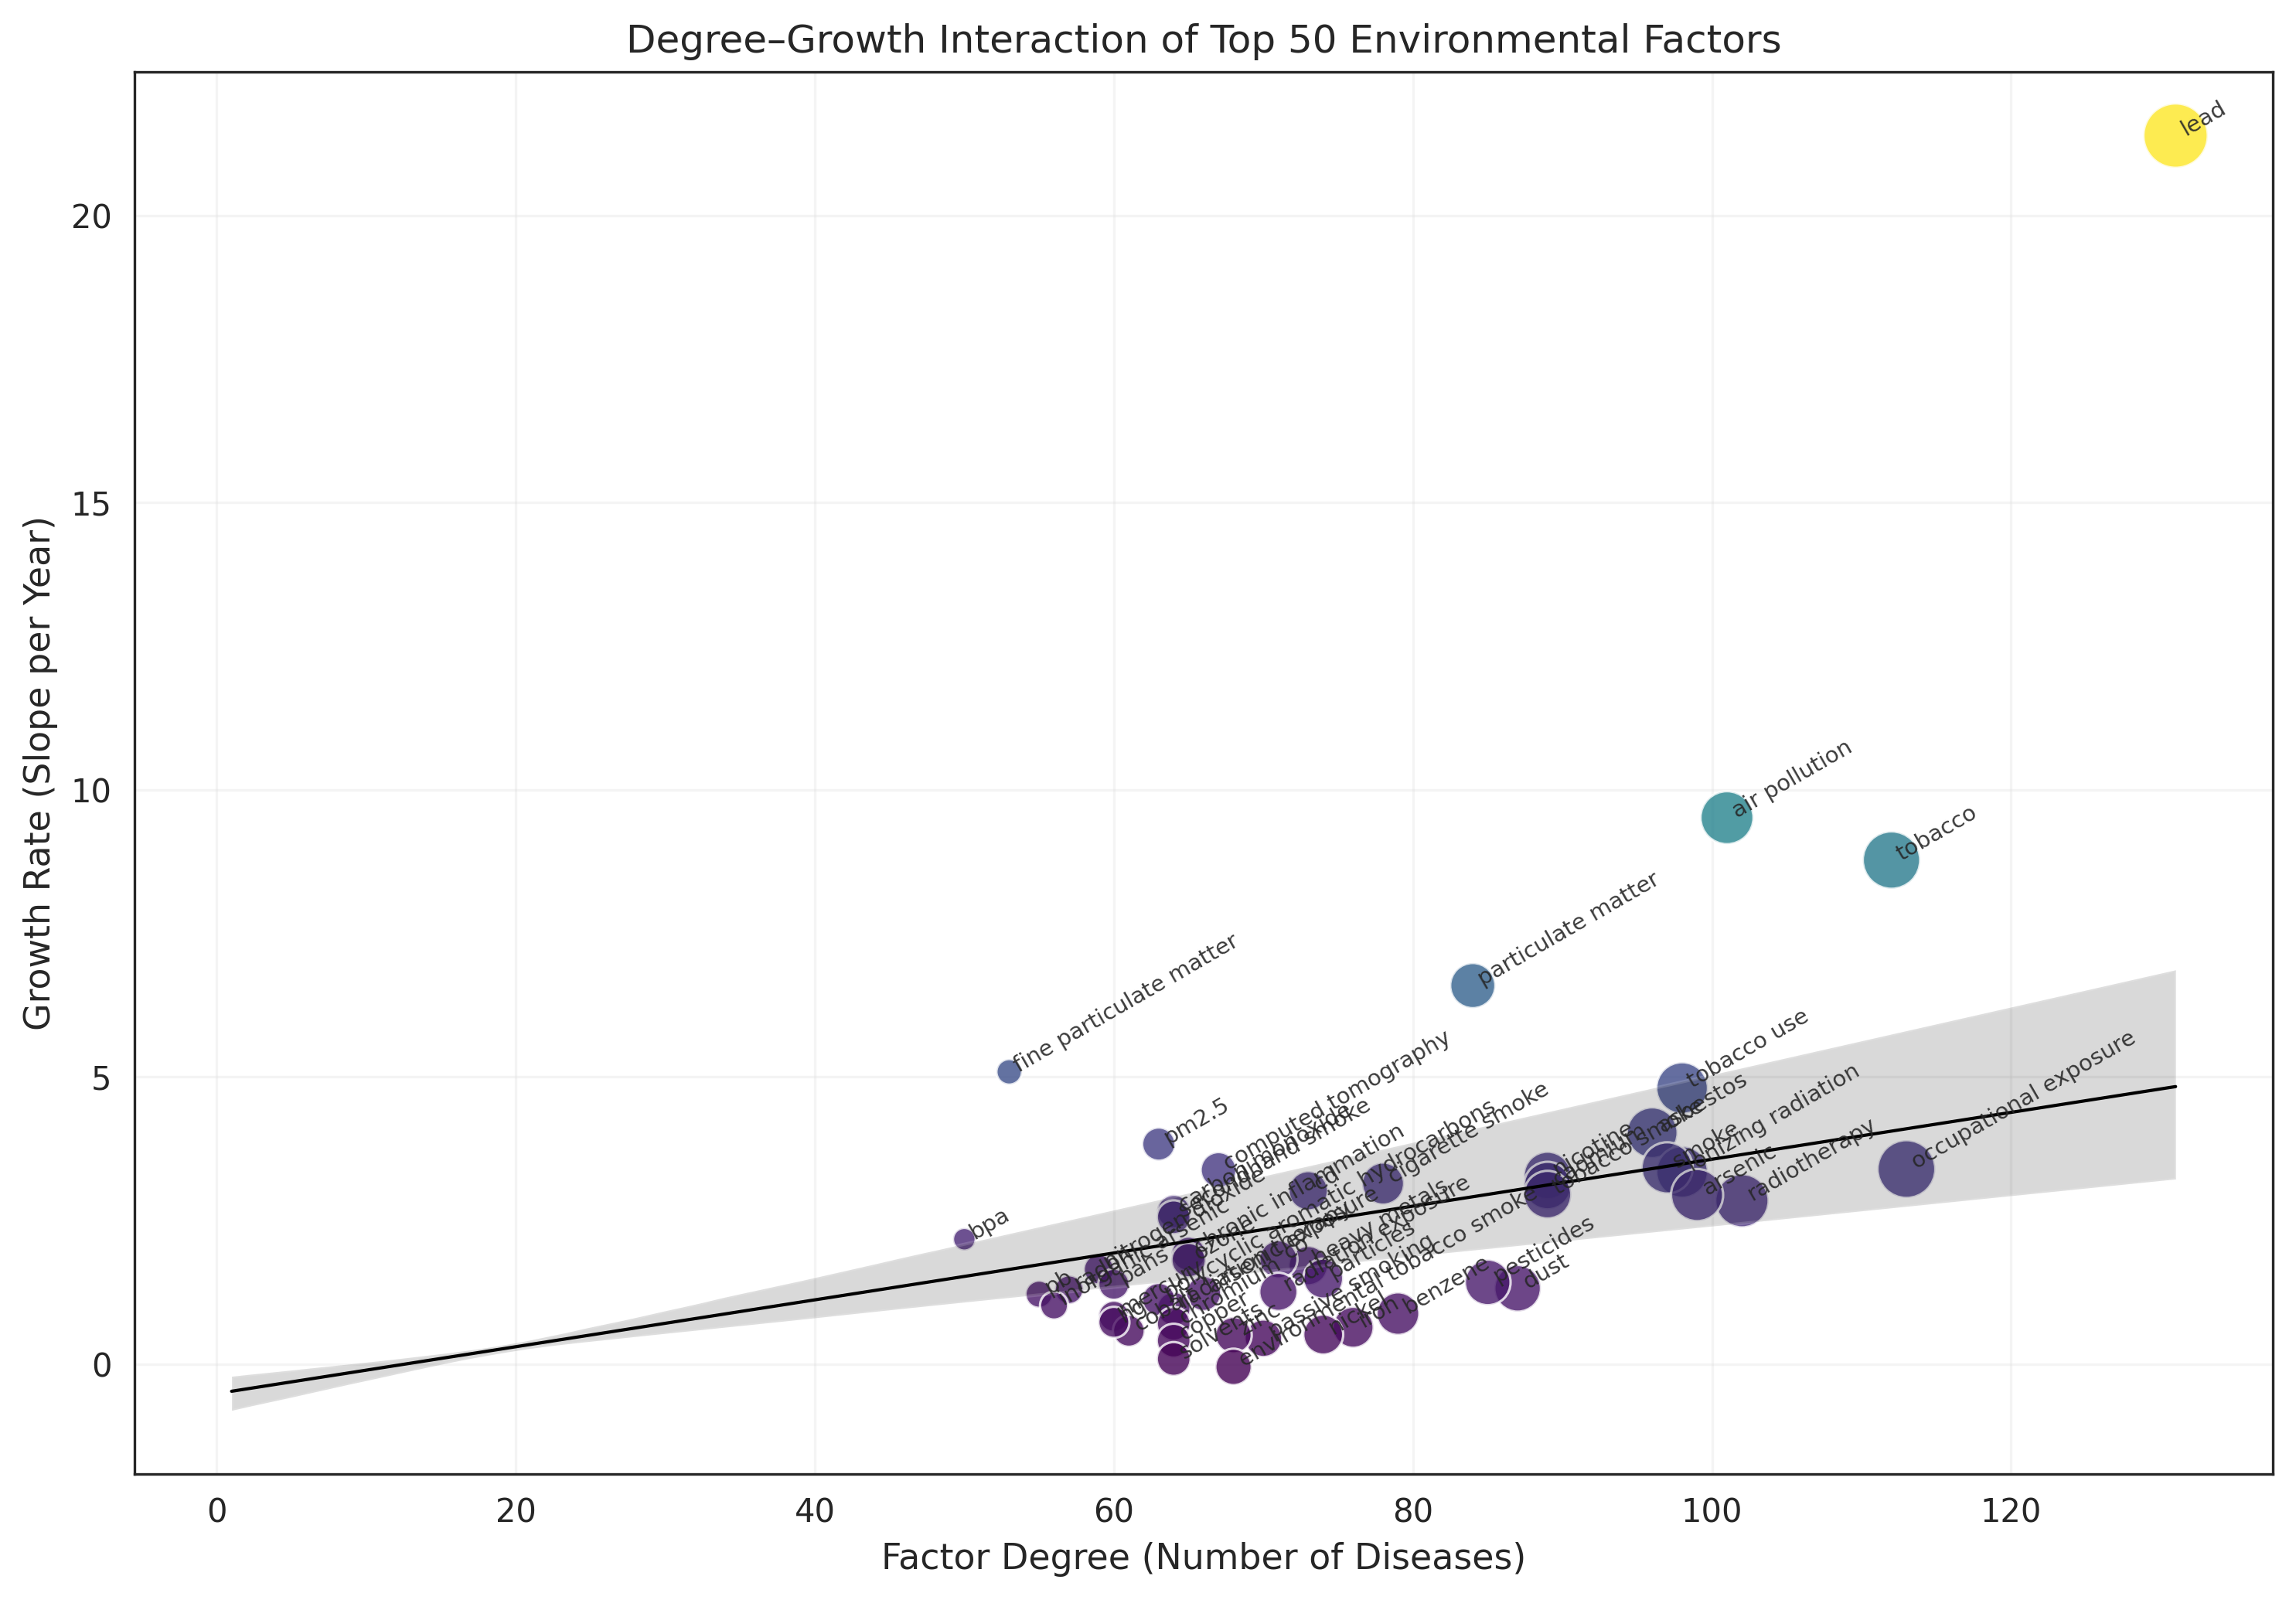

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


factor_degree = (
    df_pos.groupby("factor")["disease"]
    .nunique()
    .reset_index(name="disease_count")
)

factor_plot = factor_time_summary.merge(
    factor_degree, on="factor", how="left"
)

factor_plot["disease_count"] = factor_plot["disease_count"].fillna(1)
factor_plot["growth_rate"] = factor_plot["growth_rate"].fillna(0)

factor_plot["disease_count"] = pd.to_numeric(factor_plot["disease_count"], errors="coerce")
factor_plot["growth_rate"] = pd.to_numeric(factor_plot["growth_rate"], errors="coerce")

factor_plot = factor_plot.dropna(subset=["disease_count", "growth_rate"])

degree_norm = (factor_plot["disease_count"] - factor_plot["disease_count"].min()) / \
              (factor_plot["disease_count"].max() - factor_plot["disease_count"].min())
growth_norm = (factor_plot["growth_rate"] - factor_plot["growth_rate"].min()) / \
              (factor_plot["growth_rate"].max() - factor_plot["growth_rate"].min())

factor_plot["importance_score"] = degree_norm + growth_norm

top_factors = factor_plot.sort_values("importance_score", ascending=False).head(50)

if factor_plot["disease_count"].nunique() > 1 and factor_plot["growth_rate"].nunique() > 1:
    corr, p_value = stats.pearsonr(factor_plot["disease_count"], factor_plot["growth_rate"])
else:
    corr, p_value = np.nan, np.nan

print(f"Degree–Growth Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4e}")


sns.set_style("white")
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 300
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=top_factors,
    x="disease_count",
    y="growth_rate",
    size="disease_count",
    hue="growth_rate",
    palette="viridis",
    sizes=(50, 400),
    alpha=0.8,
    legend=False
)

sns.regplot(
    data=factor_plot,
    x="disease_count",
    y="growth_rate",
    scatter=False,
    color="black",
    line_kws={"linewidth":1}
)

for _, row in top_factors.iterrows():
    plt.text(
        row["disease_count"] + 0.1,
        row["growth_rate"],
        row["factor"],
        fontsize=7,
        rotation=30,
        alpha=0.9
    )

plt.xlabel("Factor Degree (Number of Diseases)")
plt.ylabel("Growth Rate (Slope per Year)")
plt.title("Degree–Growth Interaction of Top 50 Environmental Factors")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("high_growth.png", dpi=300)
plt.show()
